In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *

import pickle
import copy
import time
import humanfriendly

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import random
from torchmetrics.image import SpectralAngleMapper
from skimage.metrics import structural_similarity as ssim
import gc
import psutil
from multiprocessing import Pool
from scipy.optimize import nnls
from itertools import repeat
import matplotlib.patches as patches
from datetime import datetime
import pacmap
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from ipywidgets import interact, widgets, Button, Output
import psutil
from multiprocessing import Pool
from scipy.optimize import nnls

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.image import SpectralAngleMapper


device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

In [116]:


# Custom Layers

class SumToOne(nn.Module):
    """Enforces abundance sum-to-one per pixel using softmax over channels."""
    def __init__(self, dim=1):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        # x: (B, C, H, W)
        return F.softmax(x * 3.5, dim=self.dim)


# CNNAEU Encoder
class CNNAEU_Encoder(nn.Module):
    def __init__(self, in_channels, n_endmembers=5, hidden_channels=64):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_channels)
        self.do1 = nn.Dropout2d(p=0.2)

        self.conv2 = nn.Conv2d(hidden_channels, n_endmembers, kernel_size=1, padding=0)
        self.bn2 = nn.BatchNorm2d(n_endmembers)
        self.do2 = nn.Dropout2d(p=0.2)


        self.sum_to_one = SumToOne(dim=1)

    def forward(self, x):
        x = F.leaky_relu(self.do1(self.bn1(self.conv1(x))))
        x = F.leaky_relu(self.do2(self.bn2(self.conv2(x))))

        x = self.sum_to_one(x)         # enforce abundance constraint
        return x

# CNNAEU Decoder
class CNNAEU_Decoder(nn.Module):
    def __init__(self, n_endmembers, out_channels):
        super().__init__()
        # single conv layer to reconstruct spectra
        self.conv =  nn.Conv2d(n_endmembers, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.conv(x)


# Full Autoencoder
class CNNAEU(nn.Module):
    def __init__(self, in_channels, n_endmembers=5, hidden_channels=64):
        super().__init__()
        self.encoder = CNNAEU_Encoder(in_channels, n_endmembers, hidden_channels)
        self.decoder = CNNAEU_Decoder(n_endmembers, in_channels)

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon, latent


# SAD Loss
def spectral_angle_distance(y_true, y_pred, eps=1e-8):
    """
    y_true, y_pred: (B, bands, H, W)
    Returns mean SAD in radians
    """
    y_true_f = y_true.flatten(2)  # (B, bands, H*W)
    y_pred_f = y_pred.flatten(2)

    y_true_n = y_true_f / (y_true_f.norm(dim=1, keepdim=True) + eps)
    y_pred_n = y_pred_f / (y_pred_f.norm(dim=1, keepdim=True) + eps)

    cos_sim = (y_true_n * y_pred_n).sum(dim=1).clamp(-1+eps, 1-eps)
    sad = torch.acos(cos_sim)
    return sad.mean()


# Optional: Patch Extraction
def extract_patches(hsi, patch_size=16, stride=8):
    """
    hsi: (H, W, B) numpy array
    returns: (num_patches, B, patch_size, patch_size)
    """
    H, W, B = hsi.shape
    patches = []
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = hsi[i:i+patch_size, j:j+patch_size, :]
            patch = np.transpose(patch, (2,0,1))  # (B, H, W)
            patches.append(patch)
    patches = np.stack(patches)
    return torch.from_numpy(patches).float()



In [3]:
with open('../advanced_denoising/results/preprocessed_edx/20260218_120226_tile_aligned20frames_NGMeet.pkl', 'rb') as file:
    tile_NGMeet = pickle.load(file)


tile_NGMeet.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None
5,MeanFilterEDX,kernel_size=3,"(974, 974)","(974, 974, 250)",None
6,NGMeet_matlab,"sigma=0.3, nEM=10, nIter=2","(974, 974)","(974, 974, 250)",None


In [127]:
if __name__ == "__main__":

    # -----------------------------
    # Parameters
    # -----------------------------
    n_endmembers = 6
    patch_size = 32
    stride = 16

    cube = MinMax(tile_NGMeet.EDX)   # (H, W, B)
    H, W, B = tile_NGMeet.EDX_dim

    # Define patch grid ONCE
    row_starts = list(range(0, H - patch_size + 1, stride))
    if row_starts[-1] + patch_size < H:
        row_starts.append(H - patch_size)

    col_starts = list(range(0, W - patch_size + 1, stride))
    if col_starts[-1] + patch_size < W:
        col_starts.append(W - patch_size)

    print("Number of row positions:", len(row_starts))
    print("Number of col positions:", len(col_starts))
    print("Total patches:", len(row_starts) * len(col_starts))

    # Extract patches using SAME grid
    patches = []

    for i in row_starts:
        for j in col_starts:
            patch = cube[i:i+patch_size, j:j+patch_size, :]  # (patch_size, patch_size, B)
            patches.append(patch)

    patches = np.stack(patches)  # (N_patches, patch_size, patch_size, B)

    # Convert to torch tensor (N, B, H, W)
    x = torch.from_numpy(patches).permute(0, 3, 1, 2).float()
    x = x.to(device).contiguous()

    # Instantiate model
    model = CNNAEU(in_channels=B, n_endmembers=n_endmembers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    sam_loss_fn = SpectralAngleMapper(reduction="elementwise_mean").to(device)


    # Training loop
    num_epochs = 200

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        recon, latent = model(x)
        recon = recon.contiguous()

        loss = sam_loss_fn(recon, x)
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: SAM loss = {loss.item():.4f}")

Number of row positions: 60
Number of col positions: 60
Total patches: 3600
Epoch 0: SAM loss = 1.5025
Epoch 5: SAM loss = 1.4660
Epoch 10: SAM loss = 1.4557
Epoch 15: SAM loss = 1.4461
Epoch 20: SAM loss = 1.4343
Epoch 25: SAM loss = 1.4213
Epoch 30: SAM loss = 1.4079
Epoch 35: SAM loss = 1.3950
Epoch 40: SAM loss = 1.3813
Epoch 45: SAM loss = 1.3664
Epoch 50: SAM loss = 1.3498
Epoch 55: SAM loss = 1.3313
Epoch 60: SAM loss = 1.3088
Epoch 65: SAM loss = 1.2844
Epoch 70: SAM loss = 1.2554
Epoch 75: SAM loss = 1.2229
Epoch 80: SAM loss = 1.1877
Epoch 85: SAM loss = 1.1479
Epoch 90: SAM loss = 1.1048
Epoch 95: SAM loss = 1.0580
Epoch 100: SAM loss = 1.0070
Epoch 105: SAM loss = 0.9522
Epoch 110: SAM loss = 0.8930
Epoch 115: SAM loss = 0.8288
Epoch 120: SAM loss = 0.7598
Epoch 125: SAM loss = 0.6889
Epoch 130: SAM loss = 0.6166
Epoch 135: SAM loss = 0.5451
Epoch 140: SAM loss = 0.4717
Epoch 145: SAM loss = 0.4044
Epoch 150: SAM loss = 0.3451
Epoch 155: SAM loss = 0.2928
Epoch 160: SAM los

In [117]:
# After training: get latent abundance maps for full cube
# For simplicity, just run patches, then could stitch if needed
with torch.no_grad():
    latent_features = model.encoder(x)  # (N_patches, n_endmembers, patch_size, patch_size)

# Optional: extract endmembers from decoder weights
endmember_weights = model.decoder.conv.weight.data.cpu().numpy()  # (B, n_endmembers, 1, 1)
endmembers = endmember_weights.squeeze(-1).squeeze(-1)  # (B, n_endmembers)
print("Latent features shape:", latent_features.shape)
print("Endmembers shape:", endmembers.shape)

Latent features shape: torch.Size([3481, 6, 32, 32])
Endmembers shape: (250, 6)


In [118]:
full_abundance = np.zeros((H, W, n_endmembers), dtype=np.float32)
count_map = np.zeros((H, W, n_endmembers), dtype=np.float32)  # for averaging overlaps

patch_idx = 0
for i in range(0, H - patch_size + 1, stride):
    for j in range(0, W - patch_size + 1, stride):
        patch_latent = latent_features[patch_idx].cpu().numpy()  # (n_endmembers, patch_size, patch_size)
        patch_latent = np.transpose(patch_latent, (1,2,0))       # -> (H_patch, W_patch, latent_dim)
        
        full_abundance[i:i+patch_size, j:j+patch_size, :] += patch_latent
        count_map[i:i+patch_size, j:j+patch_size, :] += 1.0
        patch_idx += 1

mask = count_map > 0
full_abundance[mask] /= count_map[mask]

In [128]:

#  Switch to eval mode

model.eval()

# 
# Extract latent abundance maps
with torch.no_grad():
    latent_features = model.encoder(x)  
    # shape: (N_patches, n_endmembers, patch_size, patch_size)

latent_features = latent_features.cpu()

print("Latent features shape:", latent_features.shape)

# 3Extract endmembers

endmember_weights = model.decoder.conv.weight.data.cpu().numpy()
# shape: (bands, n_endmembers, 1, 1)

endmembers = endmember_weights.squeeze(-1).squeeze(-1)
# shape: (bands, n_endmembers)

print("Endmembers shape:", endmembers.shape)


# Stitch abundance patches back to full image

full_abundance = np.zeros((H, W, n_endmembers), dtype=np.float32)
count_map = np.zeros((H, W, n_endmembers), dtype=np.float32)

# Ensure full edge coverage
row_starts = list(range(0, H - patch_size + 1, stride))
if row_starts[-1] + patch_size < H:
    row_starts.append(H - patch_size)

col_starts = list(range(0, W - patch_size + 1, stride))
if col_starts[-1] + patch_size < W:
    col_starts.append(W - patch_size)

patch_idx = 0

for i in row_starts:
    for j in col_starts:

        patch_latent = latent_features[patch_idx].numpy()
        # (n_endmembers, patch_size, patch_size)

        patch_latent = np.transpose(patch_latent, (1, 2, 0))
        # → (patch_size, patch_size, n_endmembers)

        full_abundance[i:i+patch_size, j:j+patch_size, :] += patch_latent
        count_map[i:i+patch_size, j:j+patch_size, :] += 1.0

        patch_idx += 1

# Safe division
mask = count_map > 0
full_abundance[mask] /= count_map[mask]

print("Full abundance shape:", full_abundance.shape)

Latent features shape: torch.Size([3600, 6, 32, 32])
Endmembers shape: (250, 6)
Full abundance shape: (974, 974, 6)


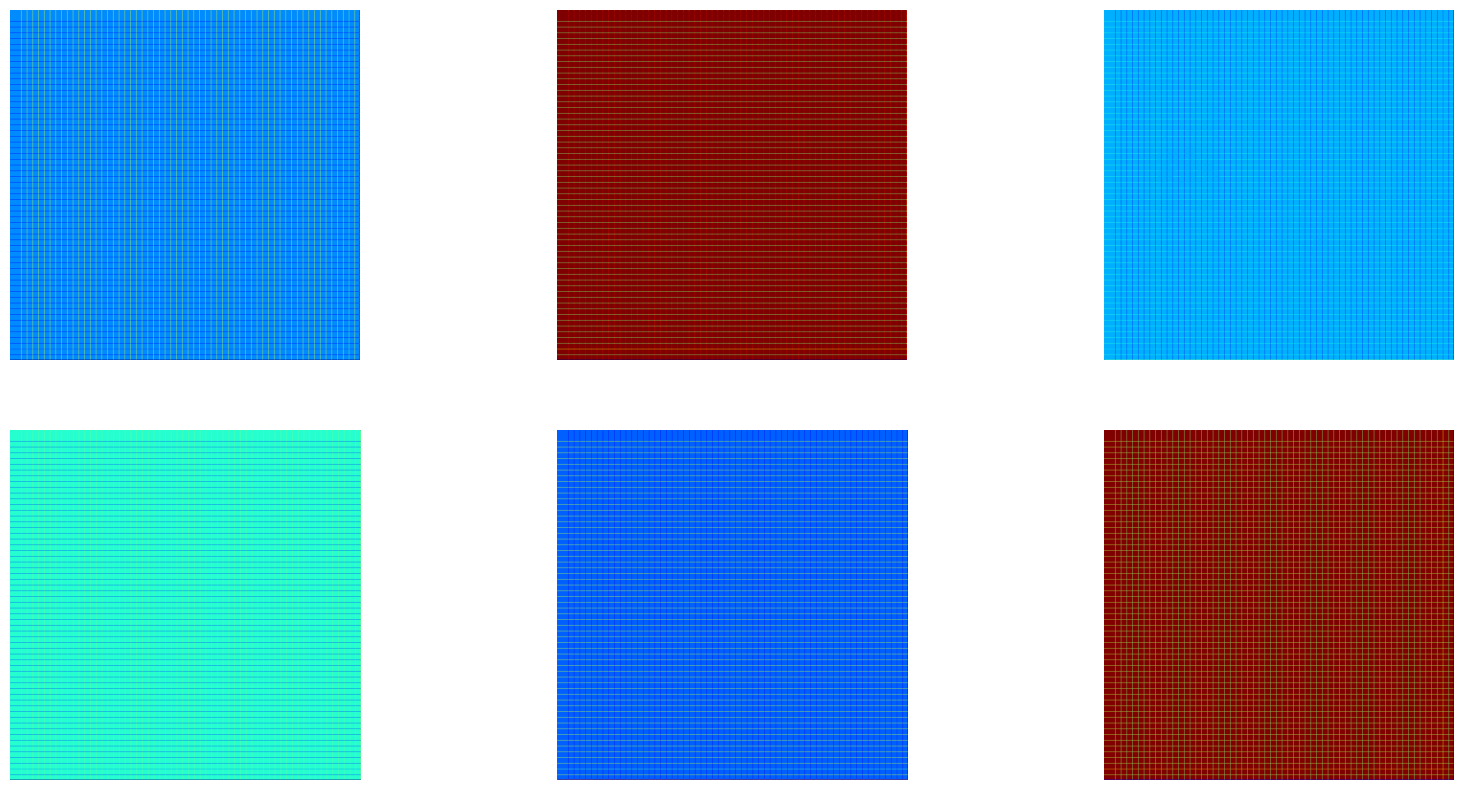

In [130]:
f,ax = plt.subplots(2,3,figsize=(20,10))

idx = 0
for axs in ax.ravel():
    try:
        axs.imshow(full_abundance[:,:,idx],cmap='jet')
        axs.axis(False)
    except:
        1
    idx+=1

In [133]:
full_abundance.sum(axis=2)

array([[0.99999994, 1.        , 1.        , ..., 1.        , 1.        ,
        1.0000001 ],
       [0.9999999 , 1.        , 1.        , ..., 0.99999994, 1.        ,
        0.99999994],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        0.99999994],
       ...,
       [1.        , 1.        , 1.        , ..., 1.        , 1.0000001 ,
        0.99999994],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        0.99999994],
       [0.99999994, 0.99999994, 1.        , ..., 0.99999994, 1.        ,
        0.99999994]], shape=(974, 974), dtype=float32)